In [ ]:
pip install mtcnn opencv-python matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 64.7 MB/s eta 0:00:00


In [9]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
from mtcnn import MTCNN

In [ ]:
img = cv2.imread('/content/person.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

detector = MTCNN()

faces = detector.detect_faces(img_rgb)

In [ ]:
for face in faces:
  x,y,w,h = face['box']
  confidence = face['confidence']

  cv2.rectangle(img_rgb, (x,y), (x + w, y + h), (0,255,0), 2)

  cv2.putText(img_rgb, f'{confidence:.2f}', (x, y-10), cv2.FONT_HERSHEY_DUPLEX, 0.8, (255, 0, 0), 2)

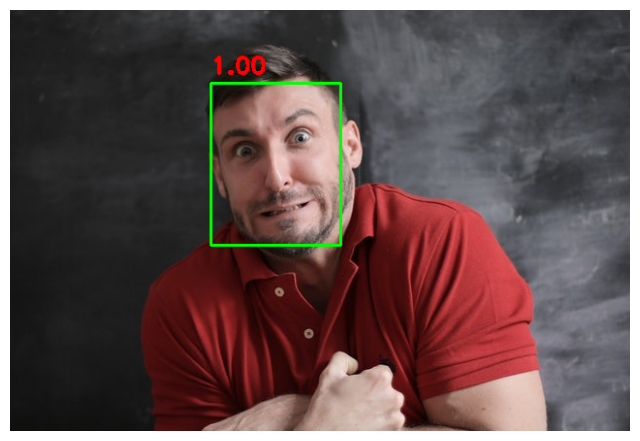

In [ ]:
plt.figure(figsize = (8,8))
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

In [1]:
pip install mediapipe opencv-python matplotlib

In [1]:
!pip uninstall mediapipe -y

!pip install mediapipe==0.10.13

Found existing installation: mediapipe 0.10.13
Uninstalling mediapipe-0.10.13:
  Successfully uninstalled mediapipe-0.10.13
  Using cached mediapipe-0.10.13-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.7 kB)
Using cached mediapipe-0.10.13-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (35.6 MB)


In [3]:
import mediapipe as mp

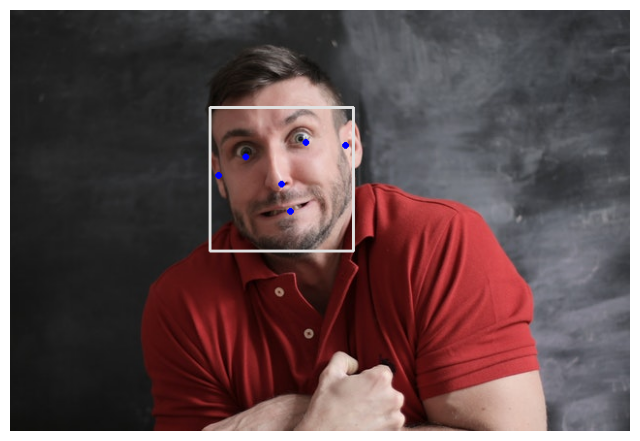

In [13]:
mp_face_detection = mp.solutions.face_detection
mp_drawing = mp.solutions.drawing_utils

face_detection = mp_face_detection.FaceDetection(
    model_selection = 0,
    min_detection_confidence = 0.5
)

img = cv2.imread('/content/person.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

results = face_detection.process(img_rgb)

if results.detections:
  for detection in results.detections:
    mp_drawing.draw_detection(img_rgb, detection)

plt.figure(figsize = (8,8))
plt.imshow(img_rgb)
plt.axis('off')
plt.show()